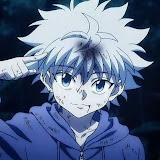

# **MADE BY XYETHER** 🤍

**Please subscribe to my** [**youtube channel**](www.youtube.com/@Xyether2) 🤍

                         click on this ☝️☝️

In [ ]:
#@title #1. **✨ Setup Environment (~5Mins)**
!pip install -q --prefer-binary pycuda tensorrt==11.0.0.114 gdown

!apt-get update -qq
!apt-get install -yqq ffmpeg

import os
import sys
import subprocess
import sysconfig

site_packages = sysconfig.get_paths()["purelib"]
trt_path = os.path.join(site_packages, "tensorrt_libs")
if os.path.exists(trt_path):
    for lib in os.listdir(trt_path):
        if lib.endswith(".so"):
            source = os.path.join(trt_path, lib)
            dest = os.path.join("/usr/lib/x86_64-linux-gnu", lib)
            if not os.path.exists(dest):
                os.symlink(source, dest)
    subprocess.run(["ldconfig"])

print("✅ Setup complete. Ready to run.")


.

.

.

In [ ]:
#@title #2. **🚀 Upscale (Anime)**
import os
import sys
import time
import gc
import queue
import shutil
import threading
import subprocess

import urllib.request
import cv2
import torch
import torch.nn.functional as F
import tensorrt as trt
import numpy as np
from tqdm import tqdm
from google.colab import files

def get_target_dims(w, h, scale_factor, speed_boost, e_type):
    if e_type == "Static":
        return 256, 256
    if speed_boost and scale_factor == 2 and (h > 720 or w > 1280):
        scale = min(1280 / w, 720 / h)
        target_w = int((w * scale) // 2 * 2)
        target_h = int((h * scale) // 2 * 2)
    else:
        target_w = int(w // 2 * 2)
        target_h = int(h // 2 * 2)
    return target_w, target_h

def enforce_max_input_limit(frame):
    h, w = frame.shape[:2]
    if w > 1920 or h > 1920:
        scale = min(1920 / w, 1920 / h)
        new_w = int((w * scale) // 2 * 2)
        new_h = int((h * scale) // 2 * 2)
        return cv2.resize(frame, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return frame

class TRTInferencePyTorch:
    def __init__(self, engine_bytes, th, tw, passes, speed_boost, scale, e_type):
        self.logger = trt.Logger(trt.Logger.WARNING)
        trt.init_libnvinfer_plugins(self.logger, "")
        self.runtime = trt.Runtime(self.logger)
        self.engine = self.runtime.deserialize_cuda_engine(engine_bytes)
        if self.engine is None:
            try:
                gpu_name = torch.cuda.get_device_name(0)
                gpu_capability = torch.cuda.get_device_capability(0)
                gpu_info = f"{gpu_name} (compute capability {gpu_capability[0]}.{gpu_capability[1]})"
            except Exception:
                gpu_info = "Unable to read the current GPU"
            trt_version = getattr(trt, "__version__", "unknown")
            raise RuntimeError(
                "❌ TensorRT could not deserialize the Xyether Anime engine.\n"
                "This release engine was built for a Google Colab NVIDIA T4 "
                "(SM 7.5) with TensorRT 11.0.0.114 and FP16.\n"
                f"Current GPU: {gpu_info}\n"
                f"Current TensorRT: {trt_version}\n\n"
                "Switch Colab to a T4 GPU, restart the runtime, rerun the setup cell, "
                "and then rerun this cell. On an L4/A100/other GPU, use the ONNX model "
                "or build a new TensorRT engine for that GPU."
            )
        self.context = self.engine.create_execution_context()
        self.input_name = self.engine.get_tensor_name(0)
        self.output_name = self.engine.get_tensor_name(1)
        try:
            in_trt_type = self.engine.get_tensor_dtype(self.input_name)
            out_trt_type = self.engine.get_tensor_dtype(self.output_name)
            self.torch_in_dtype = torch.float32 if "FLOAT" in str(in_trt_type) else torch.float16
            self.torch_out_dtype = torch.float32 if "FLOAT" in str(out_trt_type) else torch.float16
        except Exception:
            self.torch_in_dtype = torch.float16
            self.torch_out_dtype = torch.float16
        self.context.set_input_shape(self.input_name, (1, 3, th, tw))
        self.out_shape = tuple(self.context.get_tensor_shape(self.output_name))
        self.in_h, self.in_w = th, tw
        self.d_in = torch.empty((1, 3, self.in_h, self.in_w), dtype=self.torch_in_dtype, device="cuda")
        self.d_out = torch.empty(self.out_shape, dtype=self.torch_out_dtype, device="cuda")
        self.context.set_tensor_address(self.input_name, self.d_in.data_ptr())
        self.context.set_tensor_address(self.output_name, self.d_out.data_ptr())
        self.stream = torch.cuda.current_stream().cuda_stream
        self.passes = passes
        self.speed_boost = speed_boost
        self.scale = scale
        self.e_type = e_type
        self.final_h = self.out_shape[2]
        self.final_w = self.out_shape[3]

    def infer_dynamic(self, gpu_frame):
        x = gpu_frame.permute(2, 0, 1).float().div_(255.0)[[2, 1, 0], :, :].unsqueeze(0)
        for p in range(self.passes):
            if x.shape[2:] != (self.in_h, self.in_w):
                x = F.interpolate(x, size=(self.in_h, self.in_w), mode='bicubic', antialias=True)
            x = x.half() if self.torch_in_dtype == torch.float16 else x.float()
            self.d_in.copy_(x)
            self.context.execute_async_v3(stream_handle=self.stream)
            if p < self.passes - 1:
                x = self.d_out.clone().float()
                out_h, out_w = x.shape[2], x.shape[3]
                if self.speed_boost:
                    if out_h > 720 or out_w > 1280:
                        scale = min(1280 / out_w, 720 / out_h)
                        new_w = int((out_w * scale) // 2 * 2); new_h = int((out_h * scale) // 2 * 2)
                    else:
                        new_w, new_h = out_w, out_h
                else:
                    new_w = int((out_w * 0.5) // 2 * 2); new_h = int((out_h * 0.5) // 2 * 2)
                if x.shape[2:] != (new_h, new_w):
                    x = F.interpolate(x, size=(new_h, new_w), mode='bicubic', antialias=True)
        final_x = self.d_out.clone().float()
        if final_x.shape[2:] != (self.final_h, self.final_w):
            final_x = F.interpolate(final_x, size=(self.final_h, self.final_w), mode='bicubic', antialias=True)
        out = final_x.squeeze(0)[[2, 1, 0], :, :].permute(1, 2, 0).mul_(255.0).clamp_(0, 255).byte().contiguous()
        return out.cpu().numpy()

    def infer_static_tiled(self, gpu_frame):
        H, W = gpu_frame.shape[0], gpu_frame.shape[1]
        patch_size = 256
        pad_h = (patch_size - H % patch_size) % patch_size
        pad_w = (patch_size - W % patch_size) % patch_size
        x = gpu_frame.permute(2, 0, 1).float().div_(255.0)[[2, 1, 0], :, :]
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h), mode='constant', value=0.0)
        padded_H, padded_W = x.shape[1], x.shape[2]
        out_canvas = torch.empty((3, padded_H * self.scale, padded_W * self.scale), dtype=torch.float32, device="cuda")
        for y in range(0, padded_H, patch_size):
            for x_idx in range(0, padded_W, patch_size):
                patch = x[:, y:y+patch_size, x_idx:x_idx+patch_size].unsqueeze(0)
                patch = patch.half() if self.torch_in_dtype == torch.float16 else patch.float()
                self.d_in.copy_(patch)
                self.context.execute_async_v3(stream_handle=self.stream)
                out_patch = self.d_out.clone().float().squeeze(0)
                y_out = y * self.scale; x_out = x_idx * self.scale; p_out_size = patch_size * self.scale
                out_canvas[:, y_out:y_out+p_out_size, x_out:x_out+p_out_size] = out_patch
        final_out = out_canvas[:, :H * self.scale, :W * self.scale]
        out = final_out[[2, 1, 0], :, :].permute(1, 2, 0).mul_(255.0).clamp_(0, 255).byte().contiguous()
        return out.cpu().numpy()

    def infer(self, gpu_frame):
        return self.infer_static_tiled(gpu_frame) if self.e_type == "Static" else self.infer_dynamic(gpu_frame)

def run_processing(video_path, Speed_Boost, Force_1080p, codec, crf_value, auto_download):
    gc.collect()
    torch.cuda.empty_cache()

    print(f"🚀 Processing: {video_path}")

    try:
        gpu_name = torch.cuda.get_device_name(0)
        gpu_capability = torch.cuda.get_device_capability(0)
        trt_version = str(getattr(trt, "__version__", "unknown"))
    except Exception as gpu_error:
        raise RuntimeError(f"❌ CUDA GPU is not available: {gpu_error}")

    if gpu_capability != (7, 5):
        raise RuntimeError(
            "❌ This TensorRT engine is built specifically for an NVIDIA T4 "
            "(compute capability 7.5).\n"
            f"The current runtime is {gpu_name} (compute capability "
            f"{gpu_capability[0]}.{gpu_capability[1]}).\n\n"
            "Change Colab to a T4 GPU, restart the runtime, and rerun the setup "
            "and upscaling cells. For another GPU, use the ONNX model or build "
            "a TensorRT engine for that GPU."
        )

    if not trt_version.startswith("11.0.0"):
        raise RuntimeError(
            "❌ This engine was built with TensorRT 11.0.0.114.\n"
            f"The current runtime has TensorRT {trt_version}.\n\n"
            "Rerun the setup cell with tensorrt==11.0.0.114, restart the runtime, "
            "and run the cells again."
        )

    valid_img_exts = ('.png', '.jpg', '.jpeg', '.webp', '.bmp', '.tiff')
    valid_vid_exts = ('.mp4', '.mkv', '.avi', '.mov', '.webm')

    # The pipeline now always uses the 2x Xyether Anime V5 model from GitHub Releases.
    engine_url = "https://github.com/XYETHER/Xyether-Anime-Upscaler/releases/download/models/2x_XyetherAnimeV5.engine"
    engine_name = "2x_XyetherAnimeV5"
    scale_factor = 2
    num_passes = 1
    engine_type = "Dynamic"

    model_dir = "/bin/bat"
    os.makedirs(model_dir, exist_ok=True)
    engine_path = os.path.join(model_dir, f"{engine_name}.engine")
    for attempt in range(3):
        try:
            if os.path.exists(engine_path):
                os.remove(engine_path)
            request = urllib.request.Request(
                engine_url,
                headers={"User-Agent": "Mozilla/5.0"}
            )
            with urllib.request.urlopen(request, timeout=120) as response, open(engine_path, "wb") as output_file:
                shutil.copyfileobj(response, output_file)
            if os.path.exists(engine_path) and os.path.getsize(engine_path) >= 100000:
                break
        except Exception as download_error:
            print(f"⚠️ GitHub download attempt {attempt + 1}/3 failed: {download_error}")
        time.sleep(3)
    if not os.path.exists(engine_path) or os.path.getsize(engine_path) < 100000:
        sys.exit(f"❌ Error: Model download failed after retries from GitHub Releases: {engine_url}")

    with open(engine_path, "rb") as f:
        engine_bytes = f.read()
    try: os.remove(engine_path)
    except: pass

    if os.path.isdir(video_path):
        media_files = [os.path.join(video_path, f) for f in os.listdir(video_path)
                       if f.lower().endswith(valid_img_exts + valid_vid_exts)]
        output_dir = f"/content/Processed_{os.path.basename(os.path.normpath(video_path))}"
        os.makedirs(output_dir, exist_ok=True)
        is_batch = True
    else:
        media_files = [video_path]
        output_dir = "/content"
        is_batch = False

    if not media_files:
        raise ValueError("❌ No valid media files found.")

    current_model = None
    current_dims = (0, 0)

    for file_path in media_files:
        filename = os.path.basename(file_path)
        is_image = filename.lower().endswith(valid_img_exts)

        if is_image:
            frame = cv2.imread(file_path)
            if frame is None: continue
            frame = enforce_max_input_limit(frame)
            orig_h, orig_w = frame.shape[:2]
        else:
            cap = cv2.VideoCapture(file_path)
            if not cap.isOpened(): continue
            orig_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            orig_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            if orig_w > 1920 or orig_h > 1920:
                test_f = np.zeros((orig_h, orig_w, 3), dtype=np.uint8)
                sanitized_f = enforce_max_input_limit(test_f)
                orig_h, orig_w = sanitized_f.shape[:2]
            fps = cap.get(cv2.CAP_PROP_FPS)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            cap.release()

        target_w, target_h = get_target_dims(orig_w, orig_h, scale_factor, Speed_Boost, engine_type)

        if (target_w, target_h) != current_dims or current_model is None:
            if current_model is not None:
                del current_model.d_in; del current_model.d_out; del current_model
                torch.cuda.empty_cache(); gc.collect()
            current_model = TRTInferencePyTorch(engine_bytes, target_h, target_w, num_passes, Speed_Boost, scale_factor, engine_type)
            out_h, out_w = current_model.out_shape[2], current_model.out_shape[3]
            if engine_type == "Dynamic" and Force_1080p and (out_h > 1080 or out_w > 1920):
                scale_1080 = min(1920 / out_w, 1080 / out_h)
                final_w = int((out_w * scale_1080) // 2 * 2)
                final_h = int((out_h * scale_1080) // 2 * 2)
            else:
                if engine_type == "Static":
                    final_w = orig_w * scale_factor; final_h = orig_h * scale_factor
                else:
                    final_w, final_h = out_w, out_h
            current_model.final_h = final_h; current_model.final_w = final_w
            current_dims = (target_w, target_h)
            print(f"🎬 Dimensions: Input {orig_w}x{orig_h} ➜ Output {final_w}x{final_h}")

        if is_image:
            out_path = os.path.join(output_dir, f"Upscaled_{os.path.splitext(filename)[0]}.png")
            gpu_frame = torch.from_numpy(frame).to("cuda", non_blocking=True)
            out_numpy = current_model.infer(gpu_frame)
            cv2.imwrite(out_path, out_numpy)
            if not is_batch and auto_download: files.download(out_path)
        else:
            out_path = os.path.join(output_dir, f"Processed_{filename}")
            if crf_value == 0:
                encode_params = ['-c:v', codec, '-preset', 'p7', '-tune', 'lossless']
                out_pix_fmt = 'yuv444p'
            else:
                encode_params = ['-c:v', codec, '-preset', 'p7', '-tune', 'hq', '-rc', 'vbr', '-cq', str(crf_value), '-b:v', '0']
                out_pix_fmt = 'yuv420p'
            cmd = [
                'ffmpeg', '-y', '-thread_queue_size', '512',
                '-f', 'rawvideo', '-vcodec', 'rawvideo',
                '-s', f'{final_w}x{final_h}', '-pix_fmt', 'bgr24',
                '-r', str(fps), '-i', '-',
                '-i', file_path, '-map', '0:v', '-map', '1:a?'
            ] + encode_params + ['-pix_fmt', out_pix_fmt, out_path, '-hide_banner', '-loglevel', 'warning']
            proc = subprocess.Popen(cmd, stdin=subprocess.PIPE, stderr=subprocess.PIPE)
            cap = cv2.VideoCapture(file_path)
            raw_queue = queue.Queue(maxsize=16)
            def reader():
                while True:
                    ret, r_frame = cap.read()
                    if not ret: raw_queue.put(None); break
                    r_frame = enforce_max_input_limit(r_frame)
                    raw_queue.put(r_frame)
            threading.Thread(target=reader, daemon=True).start()
            with tqdm(total=total_frames, unit="frame", desc="Processing Tracking") as pbar:
                while True:
                    r_frame = raw_queue.get()
                    if r_frame is None: break
                    gpu_frame = torch.from_numpy(r_frame).to("cuda", non_blocking=True)
                    out_numpy = current_model.infer(gpu_frame)
                    proc.stdin.write(out_numpy.tobytes())
                    pbar.update(1)
            cap.release(); proc.stdin.close(); proc.wait()
            if not is_batch and auto_download: files.download(out_path)

    if is_batch:
        print(f"\n✅ Folder pipeline complete: {output_dir}")
        if auto_download:
            zip_filename = f"{output_dir}.zip"
            shutil.make_archive(output_dir, 'zip', output_dir)
            files.download(zip_filename)
    try: del engine_bytes
    except: pass
    gc.collect(); torch.cuda.empty_cache()

# ------------------- Processing params -------------------
video_path = "" #@param {type:"string"}
Speed_Boost = True #@param {type:"boolean"}
Force_1080p = False #@param {type:"boolean"}
codec = "hevc_nvenc" #@param ["h264_nvenc", "hevc_nvenc"]
crf_value = 15 #@param {type:"slider", min:0, max:23, step:1}
auto_download = True #@param {type:"boolean"}

run_processing(video_path, Speed_Boost, Force_1080p, codec, crf_value, auto_download)


#---# **My Socials**

youtube logo.png

**My** : [YOUTUBE](https://www.youtube.com/@xyether)

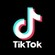

**My** : [TIKTOK](https://www.tiktok.com/@xyether_)

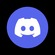

**MY** : [DISCORD SERVER](https://discord.gg/AKyds4Q57f)

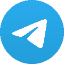

MY : [telegram channel](https://t.me/xyethertwixtors)

contact me on discord if you need help or face any problems

My username:

 [ _vixler ]